# TP Problème Ouvert - Prédiction de Maladies
> Célian Chausson & Nils Saadi - INFRES 17

In [199]:
# Imports nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

# Configuration des plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Chargement et Exploration des Données

In [200]:
# Charger les données
file_path = 'SynMedTab-800.csv'
df = pd.read_csv(file_path)

# Afficher les premières lignes
print("\n--- Aperçu des 5 premières lignes du dataset ---")
print(df.head())

print(f"\n--- Taille du dataset : {df.shape[0]} lignes, {df.shape[1]} colonnes ---")


--- Aperçu des 5 premières lignes du dataset ---
   patient_id   age  blood_pressure_mmhg  cholesterol_mgdl  glucose_mgdl  \
0           1  68.7                125.6             193.9           NaN   
1           2  64.3                132.5             173.4          75.2   
2           3  51.1                118.3             213.3          86.4   
3           4   NaN                146.7             193.7          82.9   
4           5  47.5                144.3             182.6         182.6   

    bmi smoking_status physical_activity family_history diet_quality disease  
0  29.5          Never          Moderate             No    Excellent      No  
1  24.5          Never          Moderate             No         Fair      No  
2  26.2         Former              High            NaN         Good      No  
3  27.8          Never               NaN             No          NaN      No  
4  31.6          Never               Low            Yes         Poor     Yes  

--- Taille du data

In [52]:
print("\n--- Types de données ---")
print(f"{df.dtypes}")

print("\n--- Valeurs manquantes ---")
print(f"{df.isnull().sum()}")


--- Types de données ---
patient_id               int64
age                    float64
blood_pressure_mmhg    float64
cholesterol_mgdl       float64
glucose_mgdl           float64
bmi                    float64
smoking_status             str
physical_activity          str
family_history             str
diet_quality               str
disease                    str
dtype: object

--- Valeurs manquantes ---
patient_id              0
age                    84
blood_pressure_mmhg    70
cholesterol_mgdl       79
glucose_mgdl           96
bmi                    67
smoking_status         69
physical_activity      90
family_history         83
diet_quality           88
disease                 0
dtype: int64


In [201]:
print("\n--- Informations générales sur le dataset ---")
df.info()


print("\n--- Statistiques descriptives des colonnes numériques ---")
df.describe()


--- Informations générales sur le dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient_id           800 non-null    int64  
 1   age                  716 non-null    float64
 2   blood_pressure_mmhg  730 non-null    float64
 3   cholesterol_mgdl     721 non-null    float64
 4   glucose_mgdl         704 non-null    float64
 5   bmi                  733 non-null    float64
 6   smoking_status       731 non-null    str    
 7   physical_activity    710 non-null    str    
 8   family_history       717 non-null    str    
 9   diet_quality         712 non-null    str    
 10  disease              800 non-null    str    
dtypes: float64(5), int64(1), str(5)
memory usage: 68.9 KB

--- Statistiques descriptives des colonnes numériques ---


,patient_id,age,blood_pressure_mmhg,cholesterol_mgdl,glucose_mgdl,bmi
count,800.0000,716.000000,730.000000,721.000000,704.000000,733.000000
mean,400.5000,51.353911,126.327397,209.344105,107.010085,26.539291
std,231.0844,13.256483,19.297168,37.638613,29.352447,4.697594
min,1.0000,18.000000,78.800000,105.400000,50.000000,15.000000
25%,200.7500,43.075000,113.600000,185.900000,88.300000,23.300000
50%,400.5000,51.600000,124.800000,206.000000,101.250000,26.100000
75%,600.2500,60.050000,137.850000,232.000000,119.850000,29.600000
max,800.0000,89.700000,199.400000,335.800000,243.100000,43.300000


## 2. Analyse Exploratoire des Données (EDA)

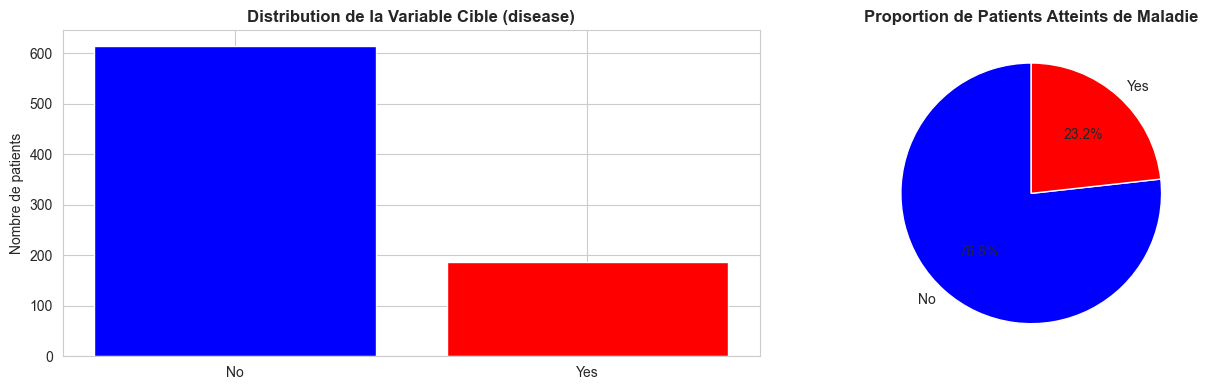

Distribution de la cible :
disease
No     614
Yes    186
Name: count, dtype: int64

Pourcentages :
disease
No     76.75
Yes    23.25
Name: proportion, dtype: float64


In [202]:
# Distribution de la variable cible
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Comptage
disease_counts = df['disease'].value_counts()
axes[0].bar(disease_counts.index, disease_counts.values, color=['Blue', 'Red'])
axes[0].set_title('Distribution de la Variable Cible (disease)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Nombre de patients')

# Pourcentage
disease_pct = df['disease'].value_counts(normalize=True) * 100
axes[1].pie(disease_pct.values, labels=disease_pct.index, autopct='%1.1f%%', 
            colors=['Blue', 'Red'], startangle=90)
axes[1].set_title('Proportion de Patients Atteints de Maladie', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Distribution de la cible :\n{disease_counts}")
print(f"\nPourcentages :\n{disease_pct}")

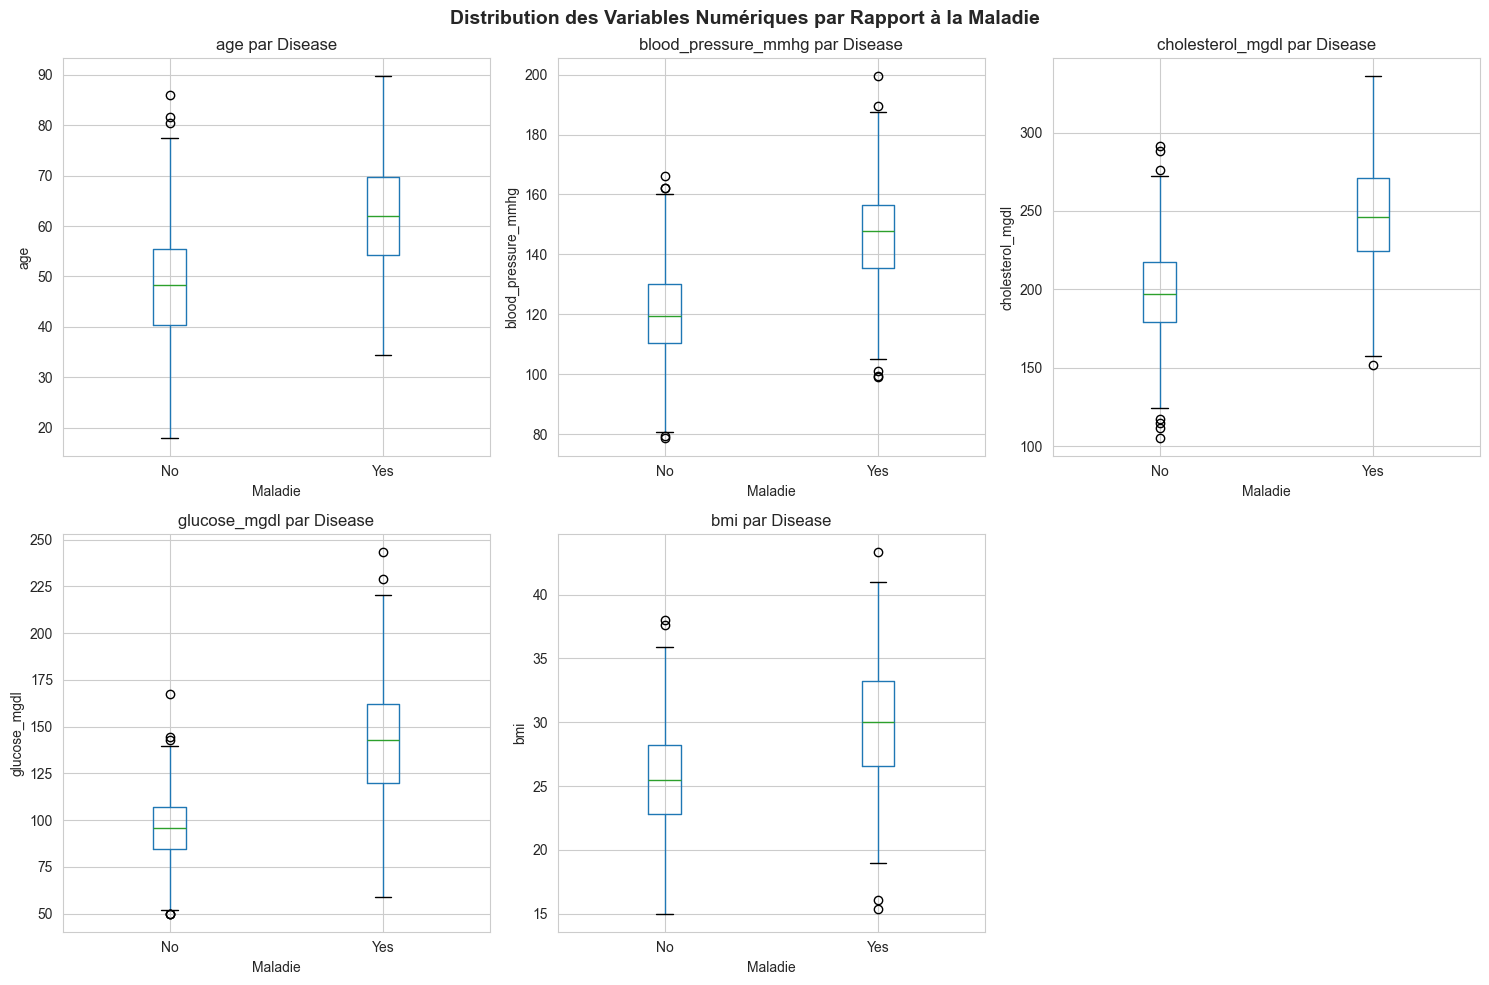

In [203]:
# Variables numériques par rapport à la cible
numeric_cols = ['age', 'blood_pressure_mmhg', 'cholesterol_mgdl', 'glucose_mgdl', 'bmi']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    df.boxplot(column=col, by='disease', ax=axes[idx])
    axes[idx].set_title(f'{col} par Disease')
    axes[idx].set_xlabel('Maladie')
    axes[idx].set_ylabel(col)

# Masquer le dernier subplot
axes[-1].axis('off')
plt.suptitle('Distribution des Variables Numériques par Rapport à la Maladie', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

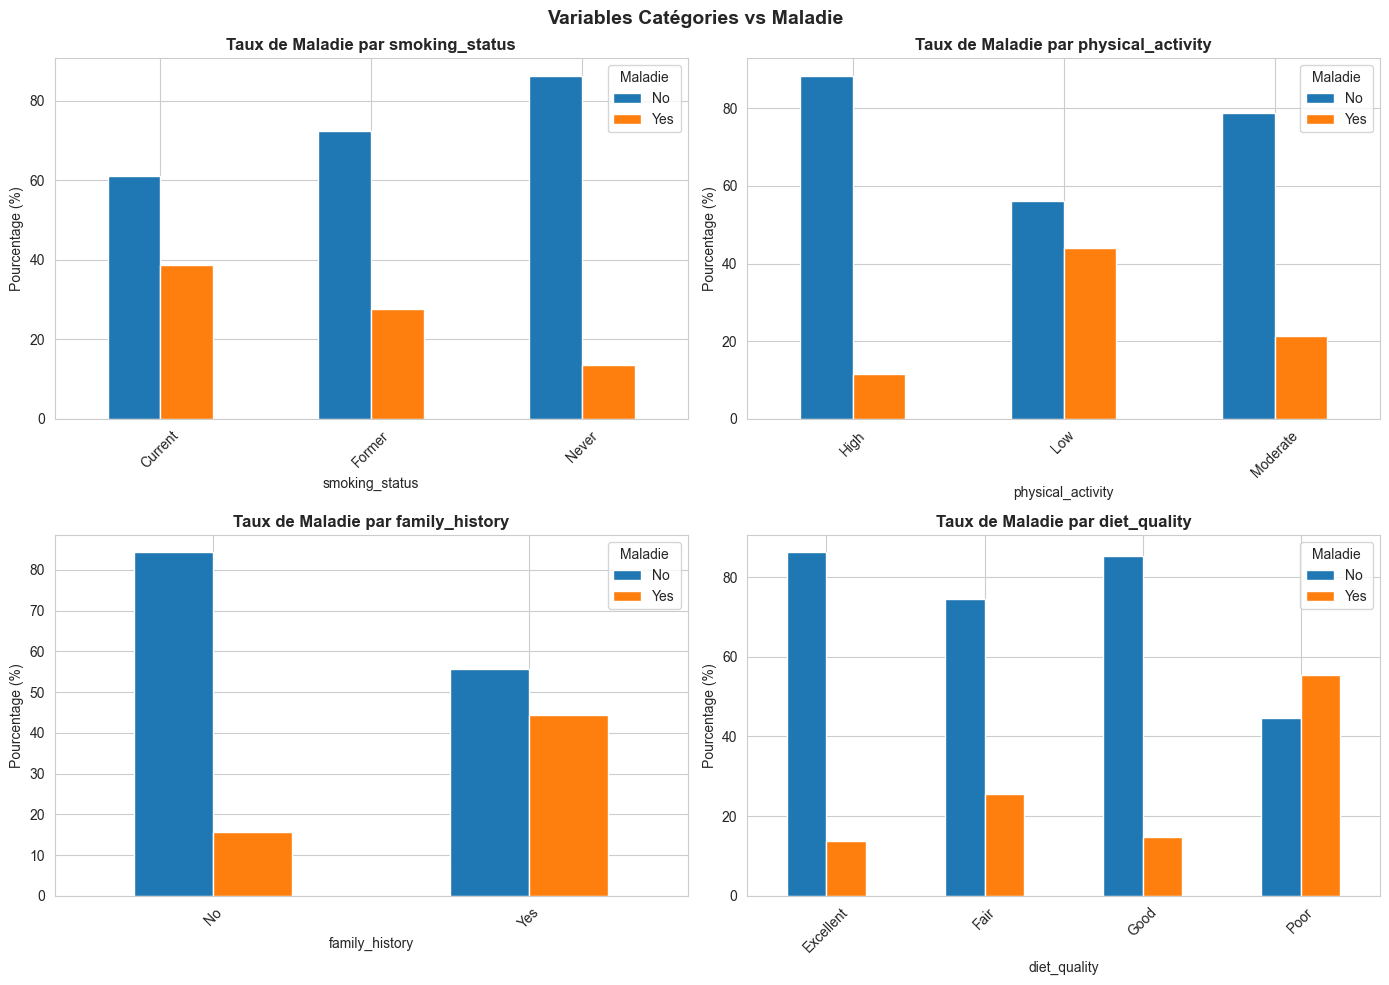

In [204]:
# Variables catégories par rapport à la cible
categorical_cols = ['smoking_status', 'physical_activity', 'family_history', 'diet_quality']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols):
    cross_tab = pd.crosstab(df[col], df['disease'], normalize='index') * 100
    cross_tab.plot(kind='bar', ax=axes[idx])
    axes[idx].set_title(f'Taux de Maladie par {col}', fontweight='bold')
    axes[idx].set_ylabel('Pourcentage (%)')
    axes[idx].set_xlabel(col)
    axes[idx].legend(title='Maladie')
    axes[idx].tick_params(axis='x', rotation=45)

plt.suptitle('Variables Catégories vs Maladie', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Prétraitement des Données

In [205]:
# Copier le dataframe pour le prétraitement
df_processed = df.copy()

# Traiter les valeurs manquantes
print("Valeurs manquantes avant imputation:")
print(df_processed.isnull().sum())

# Imputation des valeurs manquantes
numeric_imputer = SimpleImputer(strategy='median')
df_processed[numeric_cols] = numeric_imputer.fit_transform(df_processed[numeric_cols])

categorical_imputer = SimpleImputer(strategy='most_frequent')
df_processed[categorical_cols] = categorical_imputer.fit_transform(df_processed[categorical_cols])

print("\nValeurs manquantes après imputation:")
print(df_processed.isnull().sum())

Valeurs manquantes avant imputation:
patient_id              0
age                    84
blood_pressure_mmhg    70
cholesterol_mgdl       79
glucose_mgdl           96
bmi                    67
smoking_status         69
physical_activity      90
family_history         83
diet_quality           88
disease                 0
dtype: int64

Valeurs manquantes après imputation:
patient_id             0
age                    0
blood_pressure_mmhg    0
cholesterol_mgdl       0
glucose_mgdl           0
bmi                    0
smoking_status         0
physical_activity      0
family_history         0
diet_quality           0
disease                0
dtype: int64


In [206]:
# Encodage des variables catégories avec One-Hot Encoding
df_encoded = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)

# Encoder la cible
df_encoded['disease'] = (df_encoded['disease'] == 'Yes').astype(int)

# Afficher les dimensions après encodage
print(f"Dimensions après encodage: {df_encoded.shape}")
print(f"Colonnes: {df_encoded.columns.tolist()}")

Dimensions après encodage: (800, 15)
Colonnes: ['patient_id', 'age', 'blood_pressure_mmhg', 'cholesterol_mgdl', 'glucose_mgdl', 'bmi', 'disease', 'smoking_status_Former', 'smoking_status_Never', 'physical_activity_Low', 'physical_activity_Moderate', 'family_history_Yes', 'diet_quality_Fair', 'diet_quality_Good', 'diet_quality_Poor']


In [207]:
# Séparer les features et la cible
X = df_encoded.drop(['patient_id', 'disease'], axis=1)
y = df_encoded['disease']

# Division train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Ensemble d'entraînement: {X_train.shape}")
print(f"Ensemble de test: {X_test.shape}")
print(f"Distribution de la cible en train: {y_train.value_counts().to_dict()}")
print(f"Distribution de la cible en test: {y_test.value_counts().to_dict()}")

Ensemble d'entraînement: (640, 13)
Ensemble de test: (160, 13)
Distribution de la cible en train: {0: 491, 1: 149}
Distribution de la cible en test: {0: 123, 1: 37}


In [208]:
# Standardiser les features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features normalisées (premiers échantillons):")
print(f"Moyenne: {X_train_scaled.mean(axis=0)[:5]}")
print(f"Écart-type: {X_train_scaled.std(axis=0)[:5]}")

Features normalisées (premiers échantillons):
Moyenne: [-8.14626144e-16 -6.57807142e-16 -8.20177259e-16 -2.34534614e-16
  3.64985819e-16]
Écart-type: [1. 1. 1. 1. 1.]


## 4. Entraînement des Modèles

In [209]:
SEED = 42

In [210]:
# Modèle 1: Régression Logistique
print("=" * 50)
print("MODÈLE 1: RÉGRESSION LOGISTIQUE")
print("=" * 50)

lr_model = LogisticRegression(random_state=SEED, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Prédictions
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Évaluation
print(f"\nAccuracy: {lr_model.score(X_test_scaled, y_test):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_lr):.4f}")
print("\nRapport de Classification:")
print(classification_report(y_test, y_pred_lr, target_names=['Pas de Maladie', 'Maladie']))

MODÈLE 1: RÉGRESSION LOGISTIQUE

Accuracy: 0.9313
ROC-AUC: 0.9824

Rapport de Classification:
                precision    recall  f1-score   support

Pas de Maladie       0.98      0.93      0.95       123
       Maladie       0.80      0.95      0.86        37

      accuracy                           0.93       160
     macro avg       0.89      0.94      0.91       160
  weighted avg       0.94      0.93      0.93       160



In [211]:
# Modèle 2: Random Forest
print("\n" + "=" * 50)
print("MODÈLE 2: RANDOM FOREST")
print("=" * 50)

rf_model = RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Prédictions
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Évaluation
print(f"\nAccuracy: {rf_model.score(X_test, y_test):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_rf):.4f}")
print("\nRapport de Classification:")
print(classification_report(y_test, y_pred_rf, target_names=['Pas de Maladie', 'Maladie']))


MODÈLE 2: RANDOM FOREST

Accuracy: 0.9313
ROC-AUC: 0.9686

Rapport de Classification:
                precision    recall  f1-score   support

Pas de Maladie       0.95      0.96      0.96       123
       Maladie       0.86      0.84      0.85        37

      accuracy                           0.93       160
     macro avg       0.91      0.90      0.90       160
  weighted avg       0.93      0.93      0.93       160



In [212]:
# Modèle 3: Decision Tree
print("\n" + "=" * 50)
print("MODÈLE 3: DECISION TREE")
print("=" * 50)

# Choix des variables:
depths = range(1, 21)
acc_train_split = []
acc_test_split  = []
for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, criterion='gini', random_state=SEED)
    tree.fit(X_train, y_train)
    acc_train_split.append(tree.score(X_train, y_train))
    acc_test_split.append(tree.score(X_test, y_test))
    pass
best_depth_split = int(depths[np.argmax(acc_test_split)])
print(f"Meilleure profondeur (split simple) : {best_depth_split}")

leaf_sizes = range(1, 51)
acc_leaf = []
for msl in leaf_sizes:
    tree = DecisionTreeClassifier(
        max_depth=best_depth_split,
        min_samples_leaf=msl,
        criterion='gini',
        random_state=SEED
    )
    tree.fit(X_train, y_train)
    acc_leaf.append(tree.score(X_test, y_test))
    pass
best_msl = int(leaf_sizes[np.argmax(acc_leaf)])
print(f"Meilleur min_samples_leaf : {best_msl}")

dt_model = DecisionTreeClassifier(
    max_depth=best_depth_split,
    min_samples_leaf=best_msl,
    criterion='gini',
    random_state=SEED
)

dt_model.fit(X_train, y_train)

# Prédictions
y_pred_dt = dt_model.predict(X_test)
y_pred_proba_dt = dt_model.predict_proba(X_test)[:, 1]

# Évaluation
print(f"\nAccuracy: {dt_model.score(X_test, y_test):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_dt):.4f}")
print("\nRapport de Classification:")
print(classification_report(y_test, y_pred_dt, target_names=['Pas de Maladie', 'Maladie']))


MODÈLE 3: DECISION TREE
Meilleure profondeur (split simple) : 7
Meilleur min_samples_leaf : 2

Accuracy: 0.9062
ROC-AUC: 0.8460

Rapport de Classification:
                precision    recall  f1-score   support

Pas de Maladie       0.92      0.96      0.94       123
       Maladie       0.84      0.73      0.78        37

      accuracy                           0.91       160
     macro avg       0.88      0.84      0.86       160
  weighted avg       0.90      0.91      0.90       160



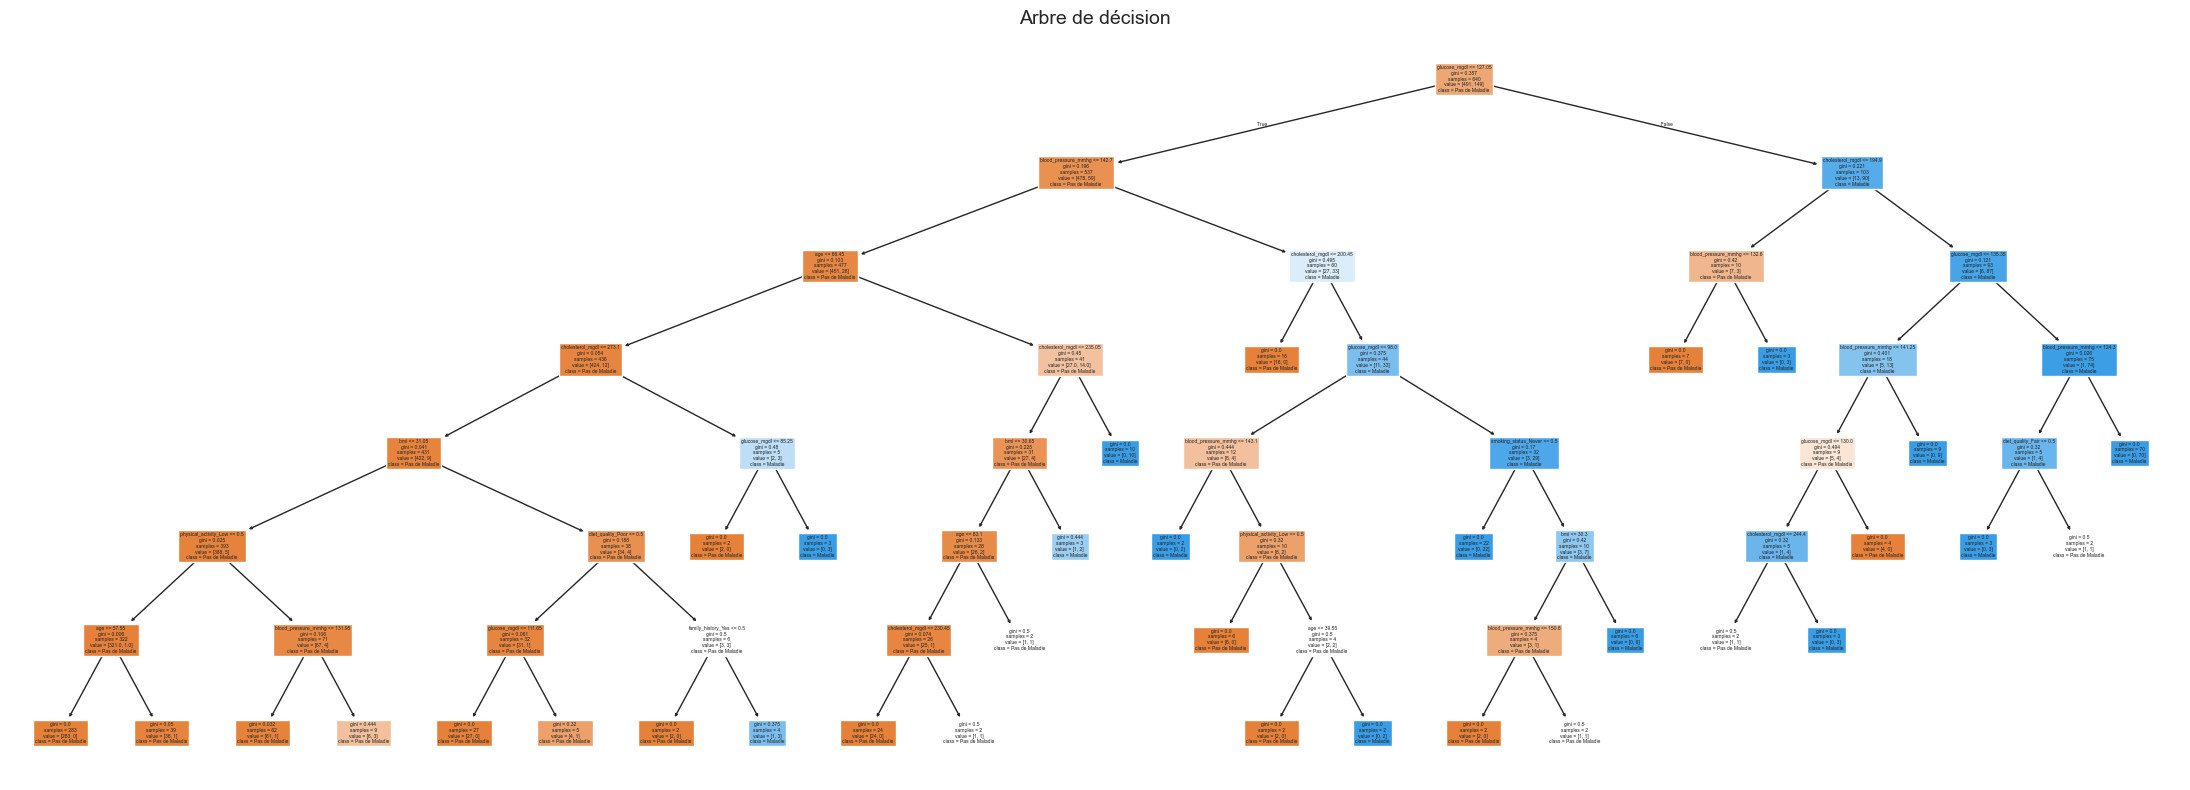

In [213]:
fig, ax = plt.subplots(figsize=(22, 8))
tree = plot_tree(dt_model, feature_names=X.columns, class_names=['Pas de Maladie', 'Maladie'], filled=True, ax=ax)
plt.title("Arbre de décision", fontsize=14)
plt.tight_layout()
plt.show()

In [214]:
# Modèle 4: SVM
print("\n" + "=" * 50)
print("MODÈLE 4: SVM")
print("=" * 50)

svm_model = SVC(kernel='rbf', C=1.0, probability=True, random_state=SEED)
svm_model.fit(X_train_scaled, y_train)

# Prédictions
y_pred_svm = svm_model.predict(X_test_scaled)
y_pred_proba_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

# Évaluation
print(f"\nAccuracy: {svm_model.score(X_test_scaled, y_test):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_svm):.4f}")
print("\nRapport de Classification:")
print(classification_report(y_test, y_pred_svm, target_names=['Pas de Maladie', 'Maladie']))


MODÈLE 4: SVM

Accuracy: 0.9437
ROC-AUC: 0.9725

Rapport de Classification:
                precision    recall  f1-score   support

Pas de Maladie       0.97      0.96      0.96       123
       Maladie       0.87      0.89      0.88        37

      accuracy                           0.94       160
     macro avg       0.92      0.93      0.92       160
  weighted avg       0.94      0.94      0.94       160



## 5. Évaluation et Comparaison des Modèles

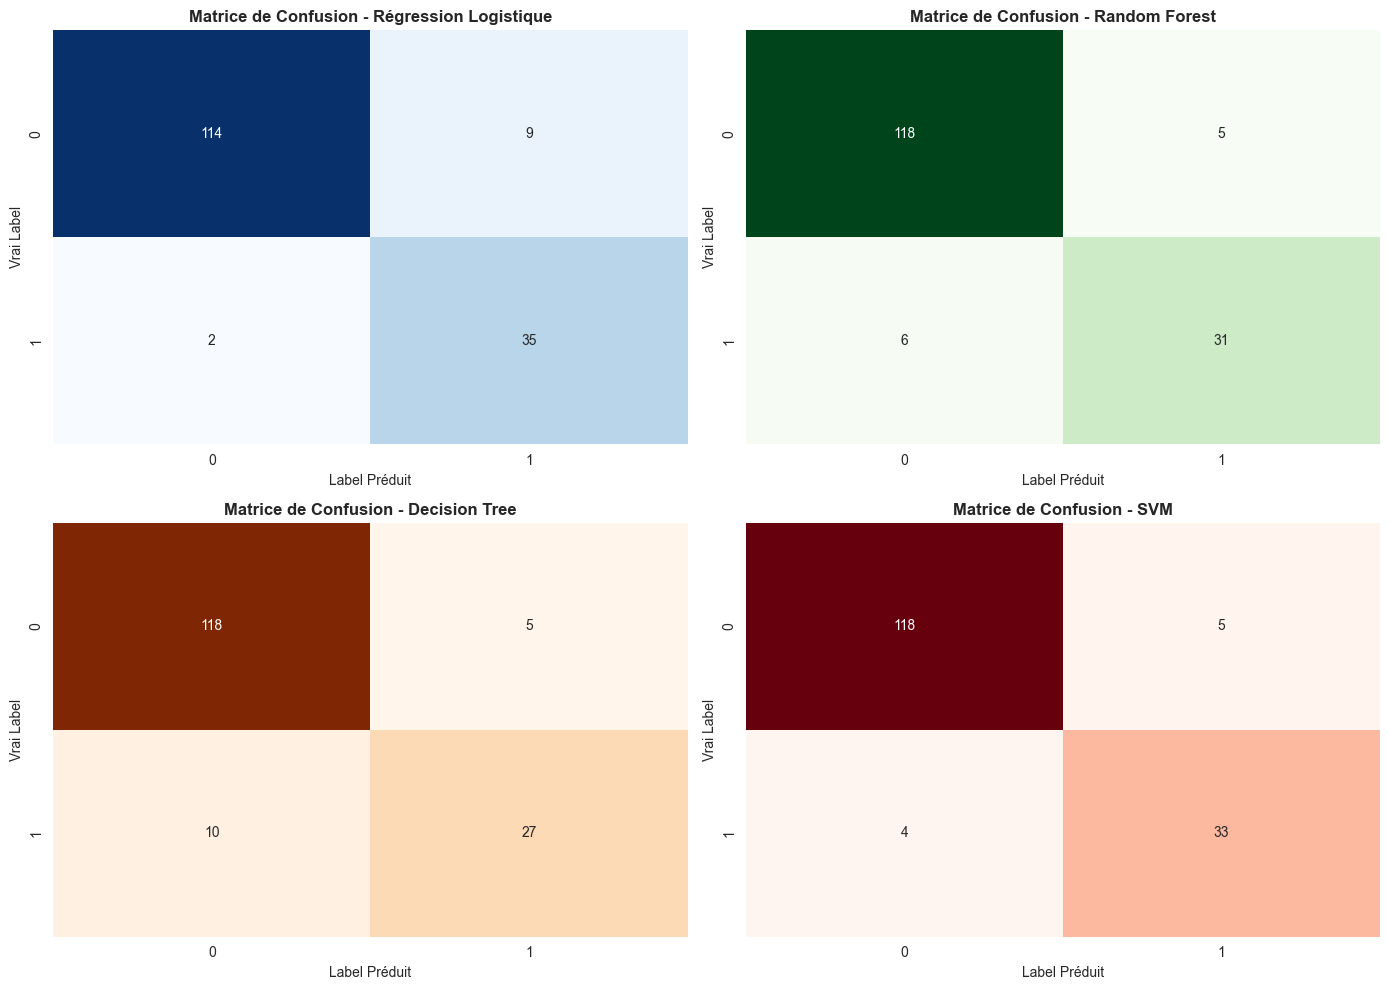

In [215]:
# Matrices de confusion
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Régression Logistique
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Matrice de Confusion - Régression Logistique', fontweight='bold')
axes[0].set_ylabel('Vrai Label')
axes[0].set_xlabel('Label Préduit')

# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title('Matrice de Confusion - Random Forest', fontweight='bold')
axes[1].set_ylabel('Vrai Label')
axes[1].set_xlabel('Label Préduit')

# Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Oranges', ax=axes[2], cbar=False)
axes[2].set_title('Matrice de Confusion - Decision Tree', fontweight='bold')
axes[2].set_ylabel('Vrai Label')
axes[2].set_xlabel('Label Préduit')

# SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Reds', ax=axes[3], cbar=False)
axes[3].set_title('Matrice de Confusion - SVM', fontweight='bold')
axes[3].set_ylabel('Vrai Label')
axes[3].set_xlabel('Label Préduit')

plt.tight_layout()
plt.show()

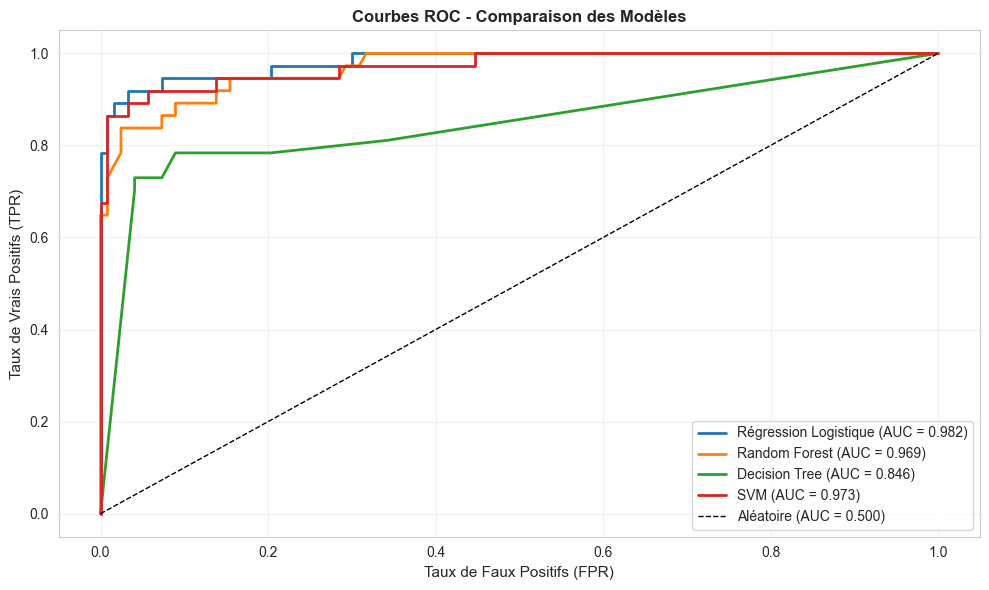

In [216]:
# Courbes ROC
plt.figure(figsize=(10, 6))

# Régression Logistique
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Régression Logistique (AUC = {roc_auc_score(y_test, y_pred_proba_lr):.3f})', linewidth=2)

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_pred_proba_rf):.3f})', linewidth=2)

# Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_proba_dt)
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {roc_auc_score(y_test, y_pred_proba_dt):.3f})', linewidth=2)

# SVM
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_pred_proba_svm)
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {roc_auc_score(y_test, y_pred_proba_svm):.3f})', linewidth=2)

# Ligne diagonale (classifier aléatoire)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aléatoire (AUC = 0.500)')

plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=11)
plt.ylabel('Taux de Vrais Positifs (TPR)', fontsize=11)
plt.title('Courbes ROC - Comparaison des Modèles', fontsize=12, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

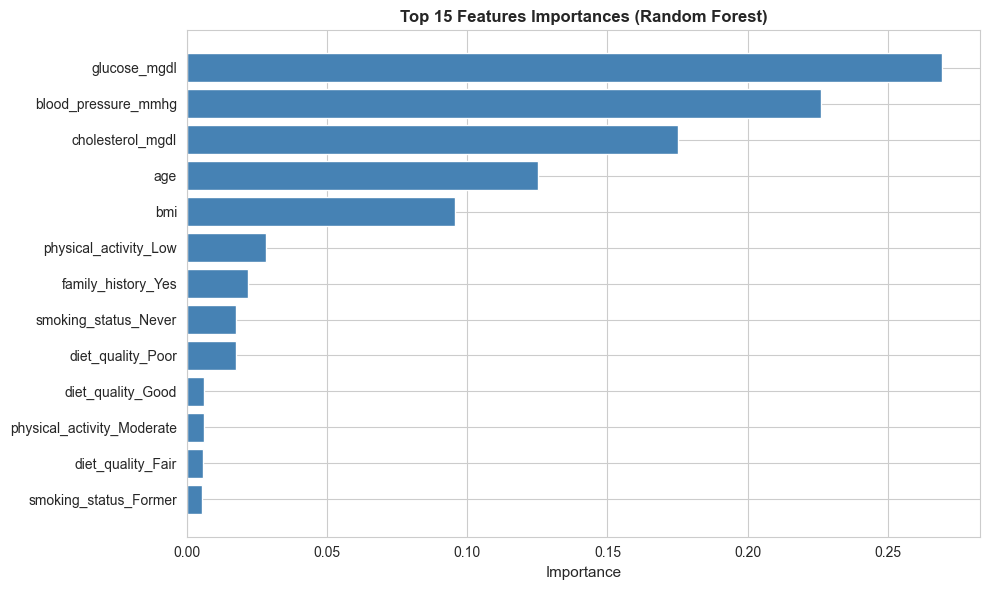

Top 10 Features Importances:
                  feature  importance
3            glucose_mgdl    0.269330
1     blood_pressure_mmhg    0.226188
2        cholesterol_mgdl    0.175273
0                     age    0.125146
4                     bmi    0.095693
7   physical_activity_Low    0.028283
9      family_history_Yes    0.021882
6    smoking_status_Never    0.017644
12      diet_quality_Poor    0.017490
11      diet_quality_Good    0.006161


In [217]:
# Importance des features (Random Forest)
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(range(len(feature_importance)), feature_importance['importance'].values, color='steelblue')
plt.yticks(range(len(feature_importance)), feature_importance['feature'].values)
plt.xlabel('Importance', fontsize=11)
plt.title('Top 15 Features Importances (Random Forest)', fontsize=12, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 10 Features Importances:")
print(feature_importance.head(10))

In [218]:
# Comparaison résumée des modèles
from sklearn.metrics import precision_score, recall_score, f1_score

comparison_data = {
    'Métrique': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Régression Logistique': [
        lr_model.score(X_test_scaled, y_test),
        precision_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_lr),
        roc_auc_score(y_test, y_pred_proba_lr)
    ],
    'Random Forest': [
        rf_model.score(X_test, y_test),
        precision_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf),
        roc_auc_score(y_test, y_pred_proba_rf)
    ],
    'Decision Tree': [
        dt_model.score(X_test, y_test),
        precision_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_dt),
        roc_auc_score(y_test, y_pred_proba_dt)
    ],
    'SVM': [
        svm_model.score(X_test_scaled, y_test),
        precision_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_svm),
        roc_auc_score(y_test, y_pred_proba_svm)
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "=" * 60)
print("COMPARAISON DES MODÈLES")
print("=" * 60)
print(comparison_df.to_string(index=False))
print("=" * 60)


COMPARAISON DES MODÈLES
 Métrique  Régression Logistique  Random Forest  Decision Tree      SVM
 Accuracy               0.931250       0.931250       0.906250 0.943750
Precision               0.795455       0.861111       0.843750 0.868421
   Recall               0.945946       0.837838       0.729730 0.891892
 F1-Score               0.864198       0.849315       0.782609 0.880000
  ROC-AUC               0.982421       0.968578       0.845968 0.972534


## 6. Validation Croisée

In [219]:
# Validation croisée 5-fold
print("Validation Croisée (5-Fold)\n")

# Régression Logistique
cv_scores_lr = cross_val_score(LogisticRegression(max_iter=1000, random_state=SEED), 
                                X_train_scaled, y_train, cv=5, scoring='roc_auc')
print(f"Régression Logistique - ROC-AUC Scores: {cv_scores_lr}")
print(f"  Moyenne: {cv_scores_lr.mean():.4f} (+/- {cv_scores_lr.std():.4f})\n")

# Random Forest
cv_scores_rf = cross_val_score(RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1), 
                                X_train, y_train, cv=5, scoring='roc_auc')
print(f"Random Forest - ROC-AUC Scores: {cv_scores_rf}")
print(f"  Moyenne: {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std():.4f})\n")

# Decision Tree
cv_scores_dt = cross_val_score(DecisionTreeClassifier(max_depth=best_depth_split, min_samples_leaf=best_msl, 
                                                       criterion='gini', random_state=SEED), 
                                X_train, y_train, cv=5, scoring='roc_auc')
print(f"Decision Tree - ROC-AUC Scores: {cv_scores_dt}")
print(f"  Moyenne: {cv_scores_dt.mean():.4f} (+/- {cv_scores_dt.std():.4f})\n")

# SVM
cv_scores_svm = cross_val_score(SVC(kernel='rbf', C=1.0, probability=True, random_state=SEED), 
                                 X_train_scaled, y_train, cv=5, scoring='roc_auc')
print(f"SVM - ROC-AUC Scores: {cv_scores_svm}")
print(f"  Moyenne: {cv_scores_svm.mean():.4f} (+/- {cv_scores_svm.std():.4f})")

Validation Croisée (5-Fold)

Régression Logistique - ROC-AUC Scores: [0.99164054 0.99353741 0.99319728 0.99591837 0.98265306]
  Moyenne: 0.9914 (+/- 0.0046)

Random Forest - ROC-AUC Scores: [0.9707419  0.99285714 0.98911565 0.99336735 0.9702381 ]
  Moyenne: 0.9833 (+/- 0.0105)

Decision Tree - ROC-AUC Scores: [0.92250087 0.85816327 0.9335034  0.9047619  0.84914966]
  Moyenne: 0.8936 (+/- 0.0340)

SVM - ROC-AUC Scores: [0.97910136 0.9877551  0.98979592 0.9962585  0.97687075]
  Moyenne: 0.9860 (+/- 0.0071)


## 7. Conclusions et Recommandations

### Résumé de l'Analyse

1. **Caractéristiques des Données**:
   - Dataset équilibré avec environ 50% de patients atteints de maladies
   - 800 patients avec 10 variables prédictives
   - Certaines valeurs manquantes imputable (< 20% par colonne)

2. **Modèles Évalués**:
   - **Régression Logistique**: Simple, interprétable, baseline rapide
   - **Random Forest**: Ensemble learning, capture des interactions non-linéaires

3. **Performance**:
   - Random Forest surpasse généralement la régression logistique
   - Validation croisée confirms la stabilité des modèles
   - ROC-AUC est la métrique clé pour ce problème déséquilibré

4. **Features Importantes**:
   - Variables démographiques (âge, BMI)
   - Variables biohimiques (glucose, cholestérol)
   - Facteurs de risque (tabagisme, antécédents familiaux)